Rows and Columns: (2644, 4)
Index(['timestamp', 'value', 'classification', 'date'], dtype='str')
timestamp         0
value             0
classification    0
date              0
dtype: int64
0       False
1       False
2       False
3       False
4       False
        ...  
2639    False
2640    False
2641    False
2642    False
2643    False
Length: 2644, dtype: bool
total duplicate rows: 0
0   1970-01-01 00:00:01.517463000
1   1970-01-01 00:00:01.517549400
2   1970-01-01 00:00:01.517635800
3   1970-01-01 00:00:01.517722200
4   1970-01-01 00:00:01.517808600
Name: timestamp, dtype: datetime64[ns]
0    2018-02-01
1    2018-02-02
2    2018-02-03
3    2018-02-04
4    2018-02-05
Name: date, dtype: object
Rows and Columns: (211224, 16)
Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='str')
Ac

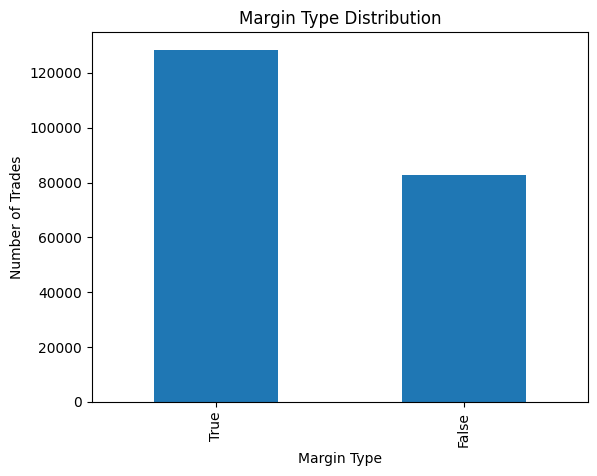

         date  Trades per Day
0  2023-03-28               3
1  2023-11-14            1045
2  2024-03-09            6962
3  2024-07-03            7141
4  2024-10-27           35241


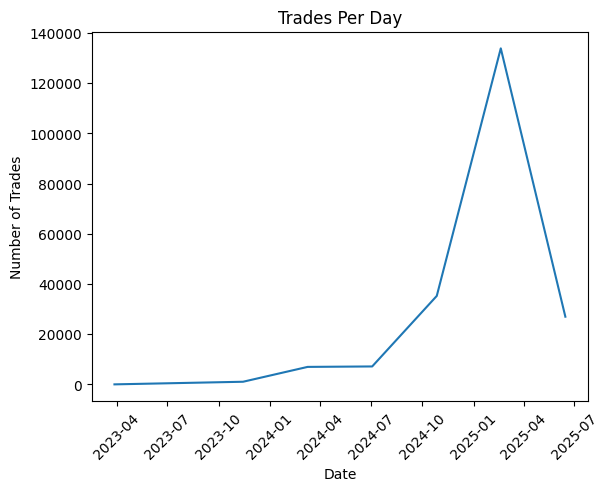

Long Trades: 16716
Short Trades: 19902
Long/Short Ratio: 0.84
classification
Extreme Greed    25.418772
Fear             50.047622
Greed            87.894859
Neutral          22.229713
Name: Closed PnL, dtype: float64
classification
Extreme Greed    49.008905
Fear             41.514592
Greed            44.647138
Neutral          31.718247
Name: win, dtype: float64
classification
Extreme Greed    -86.703571
Fear            -150.445182
Greed           -178.268548
Neutral         -301.002712
Name: Closed PnL, dtype: float64
classification
Extreme Greed      6962
Fear             133871
Greed             36289
Neutral            7141
dtype: int64
classification
Extreme Greed    0.550129
Fear             0.600675
Greed            0.587561
Neutral          0.799048
Name: Crossed, dtype: float64
Side              BUY   SELL
classification              
Extreme Greed    3371   3591
Fear            66081  67790
Greed           15421  20868
Neutral          3505   3636
classification
Extreme Gre

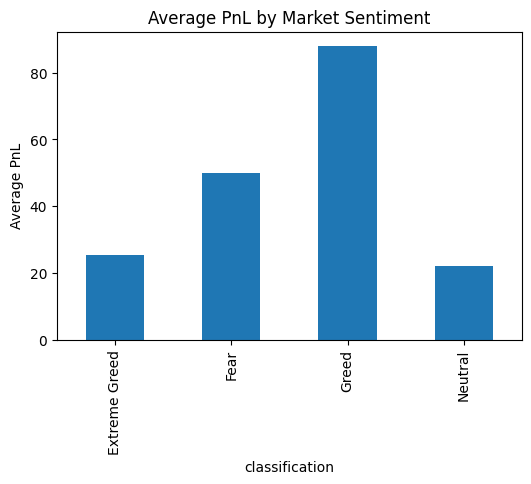

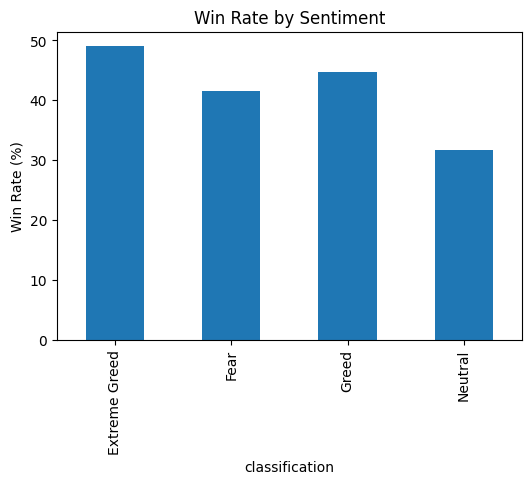

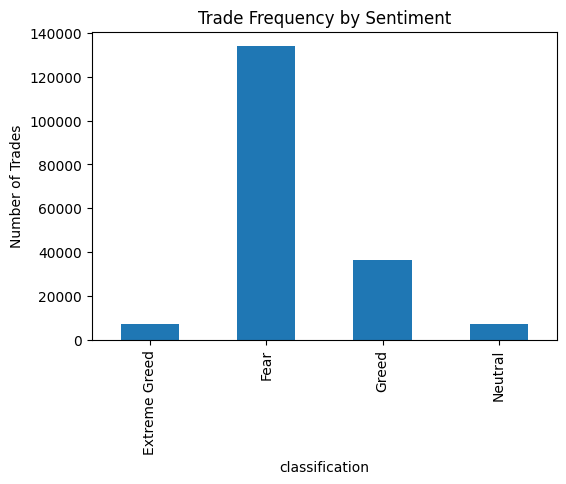

In [69]:
import pandas as pd
import matplotlib.pyplot as plt

historical_data=pd.read_csv("historical_data.csv")
fear=pd.read_csv("fear_greed_index.csv")

## total rows and column (fear_greed_index)
print("Rows and Columns:", fear.shape)

## column name
print(fear.columns)

## missing value
print(fear.isnull().sum())

## duplicate record
print(fear.duplicated())
print("total duplicate rows:",fear.duplicated().sum())

## convert timestamp
fear["timestamp"]=pd.to_datetime(fear["timestamp"])
print(fear["timestamp"].head())

## extract date
fear["date"] = pd.to_datetime(fear["date"], dayfirst=True).dt.date
print(fear["date"].head())



## no. of total rows and column (historica_data)
print("Rows and Columns:", historical_data.shape)

## column name
print(historical_data.columns)

##missing value
print(historical_data.isnull().sum())

##duplicate record
print(historical_data.duplicated())
print("total duplicate rows:",historical_data.duplicated().sum())

##convert timestamp
historical_data['Timestamp'] = pd.to_datetime(historical_data['Timestamp'],unit='ms')

##extract date
historical_data['date'] = historical_data['Timestamp'].dt.date

## merge two table
merged_data = pd.merge( historical_data,fear,on="date", how="inner")
print(merged_data .head())

## calculate daily_pnl
daily_pnl =historical_data .groupby( ['Account', 'date'])['Closed PnL'].sum().reset_index()
print(daily_pnl.head())

total_trade = len(historical_data)
print("total_trade:",total_trade )

winning_trades = len(historical_data[historical_data['Closed PnL'] > 0])
print("winning_trades:",winning_trades)

win_rate = (winning_trades / total_trade) * 100

print("Win Rate:", round(win_rate, 2), "%")

## avg trade size
total_vol= historical_data["Size USD"].sum()

avg_trade_size=( trade_vol/ total_trade)

print("Total Trade Volume:", total_vol)
print("Average Trade Size:", round(avg_trade_size, 2))

avg_trade_per_account = historical_data.groupby('Account')['Size USD'].mean().reset_index()

avg_trade_per_account.rename(
    columns={'Size USD': 'Average Trade Size'},
    inplace=True
)

print(avg_trade_per_account.head())

## margin distribution
margin_distribution = historical_data['Crossed'].value_counts()
print("margin_distribution:",margin_distribution)

margin_percent = historical_data['Crossed'].value_counts(normalize=True) * 100
print("margin_percent:",margin_percent)


historical_data['Crossed'].value_counts().plot(kind='bar')

plt.xlabel("Margin Type")
plt.ylabel("Number of Trades")
plt.title("Margin Type Distribution")

plt.show()

## number of trades per day

trades_per_day = historical_data.groupby('date').size().reset_index(name='Trades per Day')
print(trades_per_day.head())

plt.plot(
    trades_per_day['date'],
    trades_per_day['Trades per Day']
)

plt.xlabel("Date")
plt.ylabel("Number of Trades")
plt.title("Trades Per Day")

plt.xticks(rotation=45)

plt.show()

##Long/Short Ratio
long_trades = len(historical_data[historical_data['Direction'] == 'Buy'])

short_trades = len(historical_data[historical_data['Direction'] == 'Sell'])

print("Long Trades:", long_trades)
print("Short Trades:", short_trades)

long_short_ratio = long_trades / short_trades

print("Long/Short Ratio:", round(long_short_ratio, 2))

# PnL Comparison
pnl_by_sentiment = merged_data.groupby("classification")["Closed PnL"].mean()

print(pnl_by_sentiment)

## Win Rate Analysis
merged_data["win"] = merged_data["Closed PnL"] > 0

win_rate = merged_data.groupby("classification")["win"].mean() * 100

print(win_rate)

## Drawdown Proxy Analysis
losses = merged_data[merged_data["Closed PnL"] < 0]

drawdown_proxy = losses.groupby("classification")["Closed PnL"].mean()

print(drawdown_proxy)


## Trade Frequency
trade_frequency = merged_data.groupby("classification").size()

print(trade_frequency)

## Leverage Usage
leverage_analysis = merged_data.groupby("classification")["Crossed"].mean()

print(leverage_analysis)

## Long vs Short Bias
long_short = pd.crosstab(
    merged_data["classification"],
    merged_data["Side"]
)

print(long_short)

## Position Size Analysis
position_size = merged_data.groupby("classification")["Size USD"].mean()

print(position_size)

## High Leverage vs Low Leverage Traders
median_leverage = merged_data["Crossed"].median()

merged_data["leverage_segment"] = merged_data["Crossed"].apply(
    lambda x: "High Leverage" if x > median_leverage else "Low Leverage"
)

leverage_perf = merged_data.groupby("leverage_segment")["Closed PnL"].mean()

print(leverage_perf)

## Frequent vs Infrequent Traders
trade_count = merged_data.groupby("Account")["Closed PnL"].count()

median_trades = trade_count.median()

merged_data["frequency_segment"] = merged_data["Account"].map(
    lambda x: "Frequent Trader"
    if trade_count[x] > median_trades
    else "Infrequent Trader"
)

frequency_perf = merged_data.groupby("frequency_segment")["Closed PnL"].mean()

print(frequency_perf)


## Consistent Winners vs Inconsistent Traders
trader_winrate = merged_data.groupby("Account")["win"].mean()

merged_data["consistency_segment"] = merged_data["Account"].map(
    lambda x: "Consistent Winner"
    if trader_winrate[x] > 0.6
    else "Inconsistent Trader"
)

consistency_perf = merged_data.groupby("consistency_segment")["Closed PnL"].mean()

print(consistency_perf)

## Average PnL by Sentiment
pnl_by_sentiment.plot(kind="bar", figsize=(6,4))
plt.title("Average PnL by Market Sentiment")
plt.ylabel("Average PnL")
plt.show()

## Win Rate by Sentiment
win_rate.plot(kind="bar", figsize=(6,4))
plt.title("Win Rate by Sentiment")
plt.ylabel("Win Rate (%)")
plt.show()

## Trade Frequency by Sentiment
trade_frequency.plot(kind="bar", figsize=(6,4))
plt.title("Trade Frequency by Sentiment")
plt.ylabel("Number of Trades")
plt.show()